**Run online (zero install):** [Open in Colab](https://colab.research.google.com/github/PREP-NexT/PREP-SHOT/blob/main/doc/source/Quickstart.ipynb) -- click and run; needs a Google account.



**Run locally:** clone the repo and install with the `notebook` extra:

```bash
git clone https://github.com/PREP-NexT/PREP-SHOT.git
cd PREP-SHOT
pip install -e .[notebook]
jupyter lab doc/source/Quickstart.ipynb
```

In [1]:
# On Google Colab, install PREP-SHOT and clone the repo so the
# path-walk below can locate run.py / config.json. No-op on
# Local installs already have prepshot importable.
try:
    import google.colab  # type: ignore  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    import os
    if not os.path.isdir('/content/PREP-SHOT'):
        !git clone --depth=1 https://github.com/PREP-NexT/PREP-SHOT.git /content/PREP-SHOT
    %cd /content/PREP-SHOT
    !pip install --quiet -e .
    !pip install --quiet matplotlib h5netcdf


# Quickstart (30 minutes)

Goal: take a fresh checkout of PREP-SHOT, solve the shipped example, read the results, change one input, and re-solve -- all in about half an hour. No prior knowledge of capacity-expansion modeling is assumed; everything happens against the `examples/three_zone/` dataset that ships with the repo.

If anything in this page does not work for you, please open a [GitHub issue](https://github.com/PREP-NexT/PREP-SHOT/issues) -- we read every report and a broken Quickstart is the bug we most want to know about.

## Scenario background

The shipped `examples/three_zone/` dataset is inspired by real-world data, drawing primarily from the U.S. Energy Information Administration ([EIA](https://www.eia.gov/electricity/gridmonitor/dashboard/electric_overview/regional/REG-NW)), the U.S. Army Corps of Engineers ([USACE](https://www.nwd-wc.usace.army.mil/dd/common/dataquery/www/)), and the U.S. National Renewable Energy Laboratory ([NREL](https://atb.nrel.gov/electricity/2022/data)).

It models a cascading hydropower system of **15 interconnected stations** across **three balancing authorities** -- BA1, BA2, and BA3 -- each with distinct jurisdictional connections to their local reservoirs. Aside from hydropower, no other existing generation or transmission is in place; the model decides what to build from four candidate technologies (coal, wind, solar, energy storage) along an electric-mix pathway from 2020 to 2030 toward zero-carbon emissions. We use a 48-hour representative period for the analysis.

## Step 1 -- Install (5 minutes)

PREP-SHOT requires Python 3.9 or newer. Conda is recommended so the optimization-solver dependencies stay isolated:

```bash
conda create -n prep-shot python=3.11 -y
conda activate prep-shot

git clone https://github.com/PREP-NexT/PREP-SHOT.git
cd PREP-SHOT
pip install -e .
```

The default solver is the open-source [HiGHS](https://highs.dev/), installed automatically as a wheel. To use a commercial solver (Gurobi, COPT, MOSEK) instead, set `solver` in the scenario's `config.json` -- see the [Model Inputs/Outputs page](Model_input_output.rst).

## Step 2 -- Solve the shipped example (5 minutes)

The repo ships a self-contained 3-zone, 11-year example in `examples/three_zone/`. We solve it programmatically so this notebook works regardless of the working directory.

In [2]:
import sys
import os
import io
import tempfile
import pathlib

# Notebooks inherit the kernel launcher's argv; clear it so
# prepshot.set_up.parse_cli_arguments() sees no scenario flags.
sys.argv = ['notebook']

# Locate the repo root (the dir containing run.py).
repo_root = pathlib.Path.cwd()
while not (repo_root / 'run.py').exists():
    if repo_root == repo_root.parent:
        raise RuntimeError(
            'Could not find PREP-SHOT repo root; run this notebook '
            'from a checkout of PREP-NexT/PREP-SHOT.'
        )
    repo_root = repo_root.parent
scenario = repo_root / 'examples' / 'three_zone'
print(f'Scenario: {scenario}')

Scenario: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/three_zone


In [3]:
from prepshot.cli import main

# HiGHS writes its progress log via C-level stdout (file
# descriptor 1), which bypasses Python's sys.stdout. Redirect
# the file descriptor to a tempfile during the solve so the
# notebook output stays readable.
log = tempfile.NamedTemporaryFile('w+', delete=False, prefix='prepshot_solve_')
log_path = log.name
sys.stdout.flush()
saved = os.dup(1)
os.dup2(log.fileno(), 1)
cwd_before = os.getcwd()
os.chdir(scenario)  # solve_model writes output/ relative to cwd
try:
    solved = main(root_dir=str(scenario))
finally:
    sys.stdout.flush()
    os.dup2(saved, 1)
    os.close(saved)
    log.close()
    os.chdir(cwd_before)
print(f'log: {log_path}')

2026-05-05 10:08:15 INFO: Set parameter solver to value highs


2026-05-05 10:08:15 INFO: Set parameter input folder to value input


2026-05-05 10:08:15 INFO: Set parameter output_filename to value year.nc


2026-05-05 10:08:15 INFO: Set parameter time_length to value 48


2026-05-05 10:08:15 INFO: Start running 'create_model'


...

2026-05-05 10:12:11 INFO: Results are written to ./output/year.nc


2026-05-05 10:12:11 INFO: Start running 'save_to_excel'


2026-05-05 10:12:16 INFO: Finished 'save_to_excel' in 5.41 seds


2026-05-05 10:12:16 INFO: Results are written to separate excel files


log: /var/folders/y_/ypyrt83d1hl9fhjtt_ftpwg00000gn/T/prepshot_solve_nd6kj4sl


In [4]:
# Pick out the final objective value from the captured log.
with open(log_path) as f:
    log = f.read()
objective_lines = [l for l in log.splitlines() if 'Objective value' in l]
if objective_lines:
    # The solve runs `iteration_number` head iterations; each
    # prints an objective. The last one is what matters.
    print(objective_lines[-1].strip())
print(f'Solved: {solved}')


Objective value     :  1.8804965672e+11
Solved: True


On commodity hardware the default settings (48 hours, 1 representative month, 3 head iterations) finish in around 2 minutes. The solver log will report `Objective value : 1.8809...e+11`, and a NetCDF file appears under `output/`. Everything in the rest of this notebook reads from that file.

The log lines `Water head error: ...` and the warning `Failed to converge. Maximum iteration exceeded.` are normal for the default settings: PREP-SHOT runs three head-iteration rounds and reports the final residual. Bump `iteration_number` in the scenario's `config.json` if you want a tighter (slower) converged solve.

## Step 3 -- Open the results (10 minutes)

PREP-SHOT writes results in [xarray](https://docs.xarray.dev)'s NetCDF format, so any tool that reads NetCDF can consume them.

In [5]:
import xarray as xr
import json

config = json.loads((scenario / 'config.json').read_text())
# config stores the filename WITHOUT extension; the model writes
# both .nc (xarray) and .xlsx alongside each other.
output_path = (
    scenario / 'output'
    / (config['general_parameters']['output_filename'] + '.nc')
)
print(f'Reading results from: {output_path}')

ds = xr.open_dataset(output_path)
print(sorted(ds.data_vars))


Reading results from: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/three_zone/output/year.nc
['carbon', 'carbon_breakdown', 'charge', 'cost', 'cost_fix', 'cost_fix_breakdown', 'cost_newline', 'cost_newline_breakdown', 'cost_newtech', 'cost_newtech_breakdown', 'cost_var', 'cost_var_breakdown', 'gen', 'genflow', 'income', 'install', 'public_debt_newtech', 'shadow_price_demand', 'spillflow', 'trans_export']


Three things worth a first look:

**1. Total cost.** A single number, the NPV of system cost over the planning horizon.

In [6]:
print(f"Total cost: ${float(ds.cost):,.0f}")

Total cost: $188,049,656,721


**2. Installed capacity over time.** Which technologies expanded, in which zones, and when.

In [7]:
install_by_year = ds["install"].sum("zone").to_pandas()
install_by_year

tech,Coal,Solar,Wind,Storage,Grand_Coulee,Chief_Joseph,Wells,Rocky_Reach,Rock_Island,Wanapum,Priest_Rapids,Lower_Granite,Little_Goose,Lower_Monumental,Ice_Harbor,McNary,John_Day,The_Dalles,Bonneville
year,,,,,,,,,,,,,,,,,,,
2020,34.526238,0.000000,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2021,34.526238,0.000000,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2022,34.526238,0.000000,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2023,34.526238,0.000000,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2024,34.526238,19256.365123,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2025,34.526238,19256.365123,28044.058684,1.109202e-13,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2026,34.526238,26561.715951,29957.801139,6.589525e-14,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2027,34.526238,26561.715951,29957.801139,6.589525e-14,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0
2028,34.526238,26561.715951,29957.801139,6.589525e-14,5054.0,2234.0,741.0,1126.0,482.0,890.0,828.0,747.0,748.0,784.0,525.0,1022.0,1943.0,1414.0,921.0


**3. Locational marginal prices (shadow prices on demand).** This is the dual of the power-balance constraint -- the marginal cost of one extra MWh of demand at each `(hour, month, year, zone)`. Useful for diagnosing where the system is most stressed.

In [8]:
# LMP at zone BA1 in 2025, averaged over the modeled month:
lmp = ds["shadow_price_demand"].sel(zone="BA1", year=2025).mean("month")
print(lmp)

<xarray.DataArray 'shadow_price_demand' (hour: 48)> Size: 384B
array([ 0.00000000e+00,  2.33266957e-13,  2.39959157e-13,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -9.41463675e-14,  0.00000000e+00,  0.00000000e+00,  1.93438793e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])
Coordinates:
  * hour     (hour) int

Values in `shadow_price_demand` are **NPV-discounted** dollars per MWh. To recover undiscounted real-year prices, divide by the year's variable-cost factor (computed in `prepshot.load_data.compute_cost_factors`).

A minimal generation-mix chart:

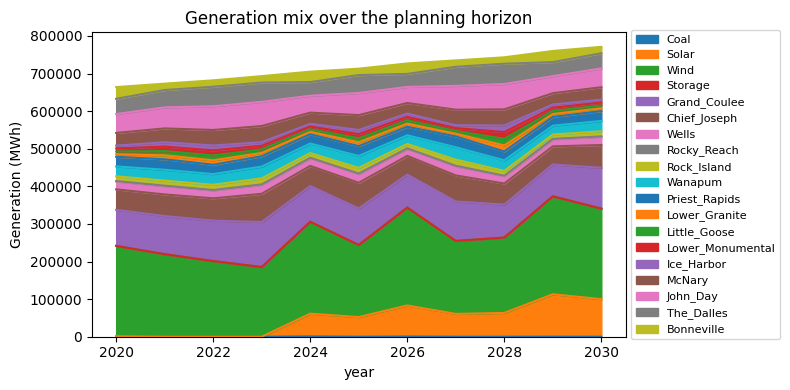

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

gen_by_tech = (
    ds["gen"]
    .sum(["hour", "month", "zone"])  # sum over time and space
    .to_pandas()                     # rows=year, cols=tech
    .clip(lower=0)                   # storage net-discharge can be ~0; clamp
)
# Drop techs that never generate (e.g. storage round-trips to ~0):
gen_by_tech = gen_by_tech.loc[:, gen_by_tech.sum() > 0]

fig, ax = plt.subplots(figsize=(8, 4))
gen_by_tech.plot.area(ax=ax)
ax.set_ylabel("Generation (MWh)")
ax.set_title("Generation mix over the planning horizon")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.tight_layout()
plt.show()


## Step 4 -- Change one input and re-solve (5 minutes)

Every input is a CSV under `examples/three_zone/`. To see how the model responds to a change, try one of these single-file edits.

**Option A -- bump demand 20% in one zone.** Open `examples/three_zone/demand.csv` (long format: `zone, year, month, hour, unit, value`) and multiply the BA1 column by 1.2 in your editor of choice. Then re-run from `examples/three_zone/` (`cd examples/three_zone && python -m prepshot`). The objective will rise -- the model has to build more capacity or import more from neighboring zones to serve the extra load. `shadow_price_demand` at BA1 should also increase in the most constrained hours.

**Option B -- introduce a carbon tax.** Open `examples/three_zone/policy_carbon_tax.csv` and replace the `value` column with a non-zero number (e.g. `50` USD/tonneCO2). Re-run from the scenario directory; the generation mix should shift away from coal and gas toward zero-carbon technologies, raising `cost_carbon` in the breakdown.

**Tip -- run scenarios without overwriting your baseline.** Save your modified file as `examples/three_zone/demand_high.csv` and run `python -m prepshot --demand=high` from inside `examples/three_zone/`. PREP-SHOT appends the suffix to the file name, so the baseline `demand.csv` is left untouched. Output goes to `examples/three_zone/output/year_high.nc`.

## Step 5 -- Where to next

- [Model Inputs/Outputs](Model_input_output.rst) -- full input / output reference, including optional carbon-market and finance modules.
- [`examples/southeast_asia/SoutheastAsia.ipynb`](../../examples/southeast_asia/SoutheastAsia.ipynb) -- a realistic case study (Lower Mekong basin, 5 countries, 57 cascading reservoirs).
- [Mathematical Notation](Mathematical_notations.rst) -- the underlying linear program.
- [Changelog](Changelog.rst) -- what's new in each release.

If you used PREP-SHOT in published work, please cite it -- see the [Citation Guide](Citations.rst). And if you ran into something rough, the fastest fix is to file an issue on [GitHub](https://github.com/PREP-NexT/PREP-SHOT/issues).